# Conditional Generative Models Enable Targeted Exploration of MAX Phase Design Space

This notebook reproduces the numerical figures and tables from the accompanying paper. Cartoon and schematic figures (Fig. 1, Fig. 6) are
omitted.

**Figures covered**

- Fig. 2 - Min-max normalised A-site well curvature distribution over the fine-tuning set
- Fig. 3 - Condition vector fidelity: measured curvature against imposed condition, for both PKV $_{\text{prefix}}$ and PKV $_{\text{residual}}$
- Fig. 4 - Novel stable structure generation rate per condition vector against the non-conditional baseline
- Fig. 5 - Stoichiometry-weighted element frequency and mean $E_{\mathrm{hull}}$ heatmap
- Fig. 7 - Elemental space of the fine-tuning dataset

**Tables covered**

- Table I - Compositionally novel candidates with MACE-predicted $E_{\mathrm{hull}}$ and ALIGNN-predicted elastic moduli
- Table II - DFT validation of the novel candidates

---

**Contact:** zccajas@ucl.ac.uk

**Repository:** `# TODO: insert repository URL`

During development the conditioning mechanisms were named PKV and Slider, corresponding respectively to PKV $_{\mathrm{prefix}}$ and PKV $_\text{residual}$ in the manuscript. The naming is retained in the underlying parquet files.


---
## 0. Environment setup

All imports are collected in the cell below. Supporting code used to reproduce individual figures has been factored out into a small
package at `./src/`. The expected layout of the repository is:

```
<repository root>/
├── max_phase_paper_reproduction.ipynb
├── structure_matcher.py
└── src/
    ├── __init__.py
    ├── max_validation.py
    ├── curvature.py -> Fig. 3
    ├── stability_sweep.py -> Fig. 4
    ├── periodic_heatmap.py -> Fig. 5
    └── generate_prompts.py
```

All raw data is pulled from the Hugging Face repository
`Jamie1701/conditional-generative-models-max-phase` via `hf_hub_download`.


In [1]:
import random
import warnings
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymatgen.core import Composition, Structure
from pymatgen.analysis.structure_matcher import StructureMatcher

from huggingface_hub import hf_hub_download, snapshot_download

from src.max_validation import (
    validate_max_phase_df,
    TRANSITION_METALS,
    A_GROUP,
)
from src.curvature import (
    calc_curvature,
    plot_cv_boxplots_two_axes,
)
from src.stability_sweep import (
    summarise_sweep,
    plot_barchart_stability_sweep,
)
from src.periodic_heatmap import make_heatmap

from src.periodic_heatmap import ELEMENT_POS, M_SITES, A_SITES, X_SITES

from src.generate_prompts import (
    generate_MAX_formulas,
    generate_MAB_formulas,
    scale_stoichiometry,
    process_and_export,
)

from src.data_key import DATASET_KEY, get_loader

warnings.filterwarnings("ignore")

HF_REPO_ID = "Jamie1701/conditional-generative-models-max-phase"


def load_dataset(dataset_name: str, config_name: Optional[str] = None) -> pd.DataFrame:
    """
    Load a dataset from HuggingFace Hub, handling both files and directories.
    
    Args:
        dataset_name: Name of the dataset (e.g., 'dataset_with_curvature', 'perturbation_experiments')
        config_name: Optional configuration for nested datasets (e.g., 'PKV')

    Returns:
        pandas DataFrame with the loaded data
    """
    # Get metadata from DATASET_KEY
    meta = DATASET_KEY.get(dataset_name)
    if not meta:
        raise KeyError(f"Dataset '{dataset_name}' not found in DATASET_KEY")
    
    # Handle nested configs
    if config_name:
        if config_name not in meta:
            raise KeyError(f"Config '{config_name}' not found in '{dataset_name}'")
        config = meta[config_name]
        # Get the HF filename from the config (usually "A_site_sweep", "hf_path", etc.)
        filename = config.get("A_site_sweep") or config.get("hf_path")
    else:
        # For simple datasets, get the hf_path
        filename = meta.get("hf_path")
    
    if not filename:
        raise ValueError(f"No filename found for {dataset_name}")
    
    # Determine if this is a file or directory
    if filename.endswith('.parquet'):
        # Single parquet file - use hf_hub_download
        path = hf_hub_download(
            repo_id=HF_REPO_ID,
            filename=filename,
            repo_type="dataset",
        )
        return pd.read_parquet(path)
    else:
        # Directory with parquet files - use snapshot_download
        repo_cache_dir = snapshot_download(
            repo_id=HF_REPO_ID,
            repo_type="dataset",
            allow_patterns=f"{filename}/*.parquet",
        )
        
        # Find and load all parquet files in the directory
        data_dir = Path(repo_cache_dir) / filename
        parquet_files = sorted(data_dir.glob("*.parquet"))
        
        if not parquet_files:
            raise FileNotFoundError(f"No parquet files found in {data_dir}")
        
        # Load and concatenate all parquet files
        dfs = [pd.read_parquet(f) for f in parquet_files]
        return pd.concat(dfs, ignore_index=True)

/var/folders/3y/7p740r7x78b0k832zjhxpylr0000gp/T/ipykernel_76101/1385778412.py:11: DeprecationWarning: This module has been moved to the pymatgen.core.structure_matcher module. This stub will be removed v2027.1. 
  from pymatgen.analysis.structure_matcher import StructureMatcher


---
## 1. Fine-tuning dataset overview (Fig. 7)

**Paper context (Methods IV.B):** The fine-tuning dataset comprises 6,179 structurally unique double transition-metal MAX phases drawn from Nykiel and Strachan (2023), supplemented with 166 compositionally unique MAB/MAX-like structures sourced from the Materials Project and NOMAD databases. Each element is coloured according to its site assignment (M, A, X, or miscellaneous), mirroring Fig. 7 of the paper.


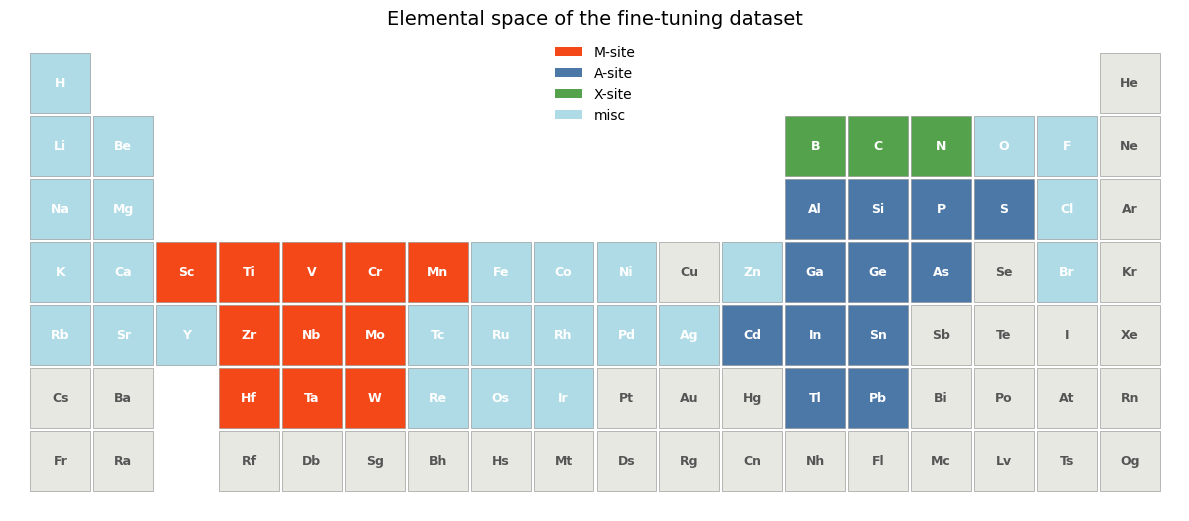

In [2]:
# Categorical periodic-table view of the fine-tuning dataset elements.
# Uses the ELEMENT_POS dict from src.periodic_heatmap for layout.

MISC = {"Fe", "Co", "Ni", "Zn", "Y", "H", 
        "Li", "Na", "K", "Rb", "Be", "Mg", "Ca",
        "Sr", "Tc", "Re", "Fe", "Ru", "Os", "Co",
        "Rh", "Ir", "Ni", "Pd", "Ag", "Zn", "O",
        "F", "Cl", "Br"}   # elements appearing only in the MAB/MAX-like supplement

CATEGORY_COLOURS = {
    "M-site": "#F54818",
    "A-site": "#4C78A8",
    "X-site": "#54A24B",
    "misc":   "#AEDBE5",
    "other":  "#e8e8e3",
}


def _classify(sym: str) -> str:
    if sym in M_SITES: return "M-site"
    if sym in A_SITES: return "A-site"
    if sym in X_SITES: return "X-site"
    if sym in MISC: return "misc"
    return "other"


fig, ax = plt.subplots(figsize=(12, 5.5))
for sym, (gx, py) in ELEMENT_POS.items():
    cat = _classify(sym)
    colour = CATEGORY_COLOURS[cat]
    ax.add_patch(plt.Rectangle(
        (gx - 0.475, -py - 0.475), 0.95, 0.95,
        facecolor=colour, edgecolor="#888888", linewidth=0.4,
    ))
    ax.text(
        gx, -py, sym,
        ha="center", va="center",
        fontsize=9, fontweight="bold",
        color="white" if cat != "other" else "#555555",
    )

ax.set_xlim(0.2, 18.8)
ax.set_ylim(-7.8, -0.2)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Elemental space of the fine-tuning dataset", fontsize=14)

# Legend
handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=CATEGORY_COLOURS[k]) for k in
    ("M-site", "A-site", "X-site", "misc")
]
ax.legend(handles, ["M-site", "A-site", "X-site", "misc"], loc="best", frameon=False)
plt.tight_layout()
plt.show()


---
## 2. A-site well curvature distribution (Fig. 2)

**Paper context (Results and Discussion):** The A-site well curvature is the second dimension of the two-dimensional condition vector and acts as a surrogate for A-site vacancy formation energy. For each structure in the fine-tuning set the A-site sublattice is displaced by $\pm 1\%$ of the $c$ lattice parameter, and $E_{\mathrm{hull}}$ is re-evaluated with MACE-MP. The second derivative is recovered via the central-difference identity

$$E''(0) = \frac{E(+\delta) + E(-\delta) - 2E(0)}{\delta^2},$$

which is then min-max normalised to $[0, 1]$ across the dataset. The resulting distribution is right-skewed, reflecting that most MAX phases
sit in relatively shallow potential wells, with a minority exhibiting strong A-site binding.

> **Note:** The curvature values in this dataset were computed using MACE-MP with default settings. The estimated noise level is approximately 1-5 meV/atom; the signal exceeded the upper bound of this range in every case, and a harmonic regime was preserved in
over 80% of structures.


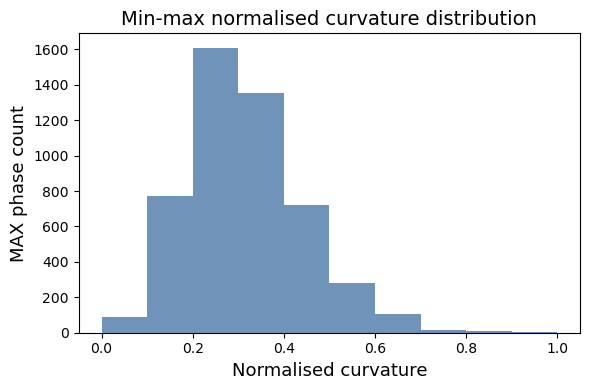

In [3]:
df_full = load_dataset('dataset_with_curvature')
df_train = df_full[df_full["split"] == "train"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df_train["curvature_norm"], bins=10, color="#4C78A8", alpha=0.8)
ax.set_xlabel("Normalised curvature", fontsize=13)
ax.set_ylabel("MAX phase count", fontsize=13)
ax.set_title("Min-max normalised curvature distribution", fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Condition vector fidelity (Fig. 3)

**Paper context (II.A):** To evaluate whether the two conditioning mechanisms faithfully propagate the imposed A-site curvature condition
into the generated structures, 1,000 structures were generated per model at each of 11 condition-vector values (0.00&ndash;1.00 in increments of 0.10), with the MXene derivative count dimension held fixed at 0.95. The *measured* A-site well curvature of each generated structure is computed using the same perturbation procedure as the underlying fine-tuning statistics.

A statistically significant positive Pearson correlation is expected between the imposed condition and the measured curvature. From the paper:

- PKV $_{\text{prefix}}$: $r = 0.56$, $p = 6.5 \times 10^{-83}$
- PKV $_{\text{residual}}$: $r = 0.69$, $p = 4.3 \times 10^{-144}$

The larger $r$ for PKV $_{\text{residual}}$ is attributed to its more robust handling of missing values in the condition vector, which avoids imputation noise that dilutes the conditioning in PKV $_{\text{prefix}}$.

> **Note:** Total generation counts are marginally less than 1,000 per vector because of post-processing filters that enforce internal CIF consistency.

### What is factored out into `src/`

The following helpers live in `src/curvature.py`:

- `calc_curvature(df, ...)` - central-difference curvature plus mean-imputation of non-finite values.
- `plot_cv_boxplots_two_axes(df1, df2, ...)` - paired boxplot used below.

And in `src/max_validation.py`:

- `validate_max_phase_df(df, formula_col=...)` - annotates rows with an `is_MAX` flag and a `MAX_info` dict.


PKV_prefix:   991/998 rows pass MAX-phase validation
PKV_residual: 994/996 rows pass MAX-phase validation


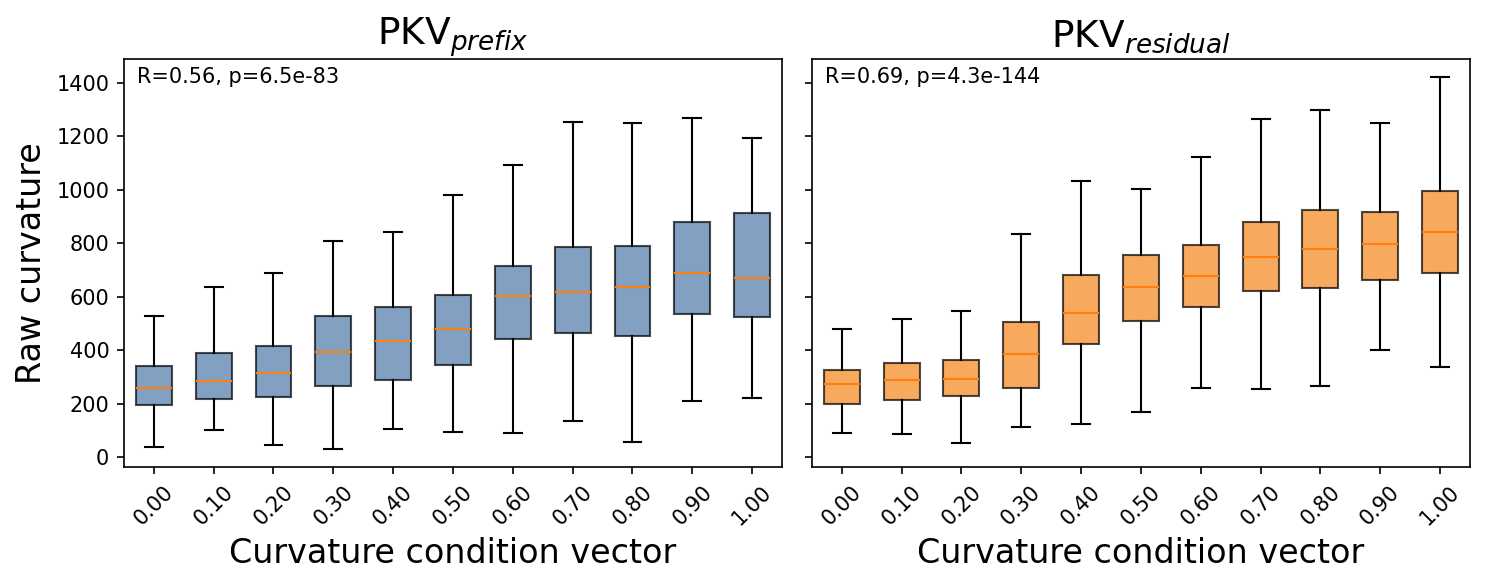

In [4]:
df_PKV = load_dataset('perturbation_experiments', 'PKV')
df_slider = load_dataset('perturbation_experiments', 'slider')

# Curvature from the raw MACE energies at 0 and +/- delta
PKV_curv = calc_curvature(df_PKV)
slider_curv = calc_curvature(df_slider)

# Reduced formula + MAX validity flag (used for inspection, not for plotting)
for frame in (PKV_curv, slider_curv):
    frame["reduced_formula"] = frame["Generated CIF"].apply(
        lambda x: Structure.from_str(x, fmt="cif").composition.reduced_formula
        if pd.notna(x) else None
    )

PKV_curv    = validate_max_phase_df(PKV_curv,    formula_col="reduced_formula")
slider_curv = validate_max_phase_df(slider_curv, formula_col="reduced_formula")

print(f"PKV_prefix:   {PKV_curv['is_MAX'].sum()}/{len(PKV_curv)} rows pass MAX-phase validation")
print(f"PKV_residual: {slider_curv['is_MAX'].sum()}/{len(slider_curv)} rows pass MAX-phase validation")

fig, _ = plot_cv_boxplots_two_axes(
    PKV_curv, slider_curv,
    cv_col="Condition Vector", curv_col="curvature",
    varying_index=1, round_to=2,
    labels=(r"PKV$_{prefix}$", r"PKV$_{residual}$"),
    title=None,
)
plt.show()

---
## 4. Novel stable structure generation rates (Fig. 4)

**Paper context (II.A):** Having established that conditioning steers individual structural features, we now test whether it also improves the *rate* at which novel metastable structures are generated. The sweep is restricted to a region biased toward MXeneable structures: MXene
derivative dimension in $\{0.75, 0.85, 0.95\}$ and A-site curvature dimension in $\{0.00, 0.10, 0.20, 0.30, 0.40\}$, yielding 15 distinct condition vectors. Each conditional model produces 19,800 structures in total (1,320 per vector); the baseline produces 19,800 unconditioned
structures for comparison.

Statistical significance of deviation from the baseline rate is assessed per condition vector using Fisher's exact test at the 5% level, with the one-sided alternative that conditioning increases the generation rate.

> **Note:** The dashed horizontal line marks the baseline mean per condition vector.

### What is factored out into `src/`

The helpers in `src/stability_sweep.py` are:

- `summarise_sweep(df_pkv, df_slider, df_baseline, ...)` - aggregate rates plus Fisher's exact tests for the condition vectors reported in the paper.
- `plot_barchart_stability_sweep(df_pkv, df_slider, ...)` - paired bar chart with the baseline reference line.


Overall sweep space: MXene in {0.75,0.85,0.95} x curvature in {0.0..0.40}
PKV_prefix:   459 novel stable structures, rate = 2.32%
PKV_residual: 415 novel stable structures, rate = 2.10%
Baseline:     644 novel stable structures, rate = 3.25%
Baseline mean per condition vector: 42.9 (of 1320 trials)

Fisher's exact test (alternative = greater) for reported condition vectors

Condition vector (0.75, 0.4):
  PKV_prefix   OR=2.36  p=1.967e-06
  PKV_residual OR=2.71  p=1.44e-08

Condition vector (0.85, 0.4):
  PKV_prefix   OR=2.09  p=5.856e-05
  PKV_residual OR=2.25  p=7.986e-06

Condition vector (0.75, 0.3):
  PKV_prefix   OR=1.40  p=0.06291
  PKV_residual OR=1.07  p=0.4138

Condition vector (0.95, 0.4):
  PKV_prefix   OR=1.50  p=0.02841
  PKV_residual OR=1.17  p=0.2612


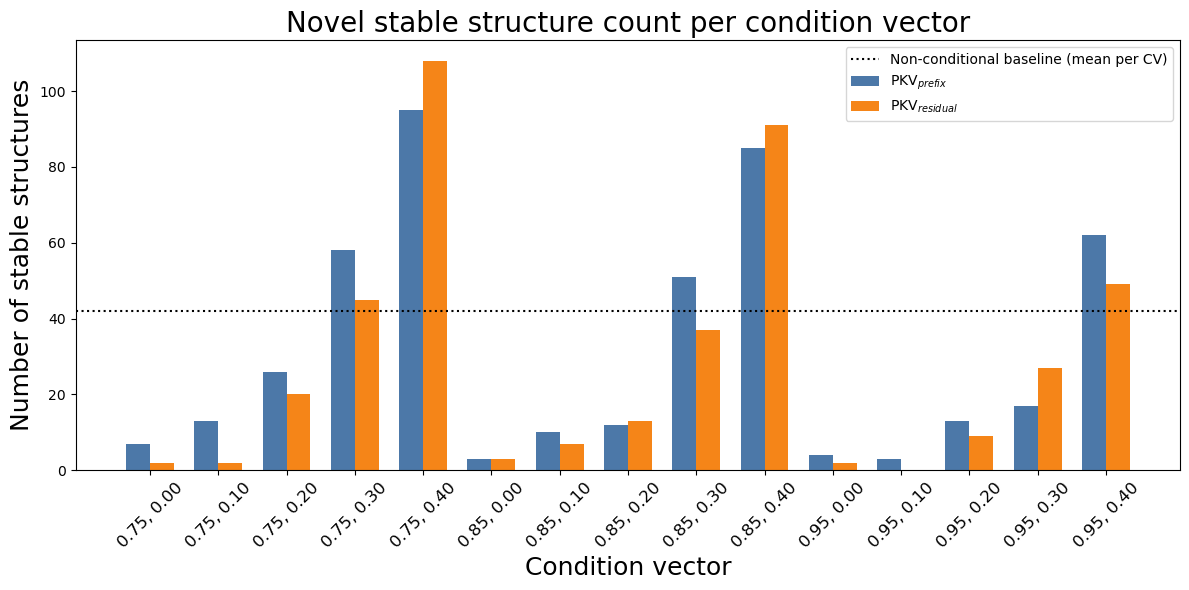

In [5]:
df_pkv_novel = load_dataset('novel_stable_structures', 'PKV')
df_slider_novel = load_dataset('novel_stable_structures', 'slider')
df_baseline_novel = load_dataset('novel_stable_structures', 'baseline')

# Print aggregate rates + per-CV Fisher's exact test (matches paper values)
sweep_summary = summarise_sweep(
    df_pkv_novel, df_slider_novel, df_baseline_novel,
    total_generations=19_800, n_condition_vectors=15,
)

# Paired bar chart reproducing Fig. 4
fig, _ = plot_barchart_stability_sweep(
    df_pkv=df_pkv_novel,
    df_slider=df_slider_novel,
    name_pkv=r"PKV$_{prefix}$",
    name_slider=r"PKV$_{residual}$",
    baseline=len(df_baseline_novel) // 15,
)
plt.show()

---
## 5. Element frequency and mean $E_{\mathrm{hull}}$ heatmap (Fig. 5)

**Paper context (II.B):** Structures are first filtered against the symmetry-based novelty thresholds of Methods IV.G (0.1 &Aring;
symmetry equivalence, 0.3 &Aring; site equivalence, 20% lattice parameter variation, 5&deg; lattice-angle tolerance), the metastability
criterion $E_{\mathrm{hull}} < 0.1$ eV/atom, and the stoichiometric constraint of $M_{n+1}AX_n$. The resulting set of novel stable
structures is then summarised per element:

- **Upper-left triangle:** stoichiometry-weighted element frequency
- **Lower-right triangle:** mean $E_{\mathrm{hull}}$ (eV/atom)

X-site elements (C, N, B) are excluded because they resolve uniformly. Key observations consistent with the paper:

- Ti dominates M-site frequency (573), with a mean $E_{\mathrm{hull}}$ of 0.042 eV/atom, recovering the experimental prominence of Ti-based MAX phases.
- Ta has the lowest mean $E_{\mathrm{hull}}$ of any M-site element (0.032 eV/atom) despite ranking fifth by frequency.
- Hf has a comparatively low mean $E_{\mathrm{hull}}$ (0.039 eV/atom) while potentially being an underrepresented species in recent literature, flagging it as a candidate for further study.
- Al has the lowest mean $E_{\mathrm{hull}}$ of any A-site element (0.031 eV/atom), consistent with its prevalence in synthesised MAX phases.

### What is factored out into `src/`

The heatmap code lives in `src/periodic_heatmap.py`. The only public entry point needed here is `make_heatmap(df_pkv, df_slider, ...)`, which stacks the two sources, computes per-element statistics, prints a tabular summary, and renders the Bokeh figure.

### Expected output

The cell prints three tables to console:

**Table 1: M-site elements** (transition metals ranked by frequency)
- `element`: Atomic symbol
- `site`: Site classification (M-site, A-site, or other)
- `freq`: Total stoichiometry-weighted element count across all novel structures
- `freq_lt_005`: Stoichiometry-weighted count restricted to E_hull < 0.05 eV/atom (deep-stable subset)
- `n_comp`: Number of unique chemical compositions containing this element
- `n_structs`: Number of stable structures (E_hull < filter threshold, default 0.25 eV/atom)
- `mean_ehull`: Mean energy above convex hull for structures containing this element (eV/atom)
- `median_ehull`: Median E_hull (eV/atom)
- `std_ehull`: Standard deviation of E_hull (eV/atom)
- `pct_deep`: Percentage of structures deep-stable (E_hull < 0.025 eV/atom)

**Table 2: A-site elements** (group 13–16 metals, same columns as Table 1)

**Table 3: Top frequency for E_hull < 0.05 eV/atom**
- Subset of columns (element, site, freq_lt_005, freq, mean_ehull) ranked by the most-stable occurrences

**Figure:** An interactive Bokeh periodic table with split-diagonal cells:
- Upper-left triangle: element frequency
- Lower-right triangle: mean E_hull

In [6]:
_ = make_heatmap(
    df_pkv=df_pkv_novel,
    df_slider=df_slider_novel,
    freq_palette="cividis",
    ehull_palette="inferno",
    output_path=str(Path("demo_heatmap.html").resolve()),
    show_plot=True,
    period_font_size="10pt",
    period_x_offset=0.01,
    png_path="auto",
    ehull_filter=0.15,
    print_analysis=True,
)


[info] Stacked 874 rows from 2 dataframes

Element analysis summary (stability-validated set)

M-site elements:
element   site  freq  freq_lt_005  n_comp  n_structs  mean_ehull  median_ehull  std_ehull  pct_deep
     Ti M-site 573.0        238.0     106        216    0.042156      0.043731   0.038127 37.962963
     Sc M-site 454.0        182.0      86        179    0.039582      0.048616   0.047390 31.843575
     Hf M-site 447.0        189.0      85        169    0.039280      0.037120   0.035228 38.461538
     Zr M-site 408.0        159.0      85        159    0.046475      0.049881   0.034088 21.383648
     Ta M-site 396.0        172.0      78        147    0.031544      0.038170   0.047210 36.734694
     Nb M-site 395.0        160.0      77        138    0.040331      0.038775   0.036467 40.579710
      V M-site 341.0        106.0      53        127    0.047396      0.059462   0.037647 28.346457
     Mo M-site 189.0         72.0      30         80    0.045351      0.051186   0.03352

---
## 6. Novel compositions, MACE predictions (Table I)

**Paper context (II.C):** Across all non-compositional generations from both conditional models and all condition vectors, a set of out-of-sample compositions (absent from both the base training corpus and the fine-tuning set) were identified as stable by MACE
($E_{\mathrm{hull}} < 0.1$ eV/atom). Bulk and shear moduli were subsequently predicted using ALIGNN.

The shear-to-bulk modulus ratio ($G/B$) generally falls between 0.4 and 0.6 across the ten candidates, a range typically indicative of ductility in MAX phases. To the best of our knowledge, only $\mathrm{Zr_3GeC_2}$ (DFT-verified stable at the PBE/GGA level by Das et al., 2023) has been previously investigated explicitly in the literature.

> **Note:** Duplicate compositions from independent experimental runs appear in the table. In the manuscript we quote only the lowest-
$E_{\mathrm{hull}}$ occurrence, but all instances are retained here for completeness. $\mathrm{HfZr_2Sc_2}$ is omitted from the paper as it
lacks a valid A-site.


In [7]:
df_MAX_MACE_candidates = load_dataset('MACE_candidates')
df_MAX_MACE_candidates

,reduced_formula,Prompt,Condition Vector,ehull_mace_og,Generated CIF
0,Hf2ScInN2,<bos>\ndata_[,"[0.95, 0.4]",0.028320,\ndata_Hf4Sc2In2N4\n_symmetry_space_group_name...
1,HfZr2CdC2,<bos>\ndata_[,"[0.75, 0.30000000000000004]",-0.047772,\ndata_Hf2Zr4Cd2C4\n_symmetry_space_group_name...
2,HfZr2ScC2,<bos>\ndata_[,"[0.85, 0.30000000000000004]",0.045678,\ndata_Hf2Zr4Sc2C4\n_symmetry_space_group_name...
3,Sc2PbWC2,<bos>\ndata_[,"[0.95, 0.30000000000000004]",0.085254,\ndata_Sc4Pb2W2C4\n_symmetry_space_group_name_...
4,Sc2TaInN2,<bos>\ndata_[,"[0.95, 0.2]",0.095469,\ndata_Sc4Ta2In2N4\n_symmetry_space_group_name...
5,ScTi2CdC2,<bos>\ndata_[,"[0.75, 0.4]",0.086231,\ndata_Sc2Ti4Cd2C4\n_symmetry_space_group_name...
6,ZrSi(WC)2,<bos>\ndata_[,"[0.75, 0.2]",0.099494,\ndata_Zr2Si2W4C4\n_symmetry_space_group_name_...
7,ZrTi2SnC2,<bos>\ndata_[,"[0.85, 0.30000000000000004]",0.042569,\ndata_Zr2Ti4Sn2C4\n_symmetry_space_group_name...
8,TaGe(MoC)2,<bos>\ndata_[,"[1.0, 0.5]",-0.005148,\ndata_Ta2Mo4Ge2C4\n_symmetry_space_group_name...
9,VGe(WC)2,<bos>\ndata_[,"[0.5, 1.0]",0.099990,\ndata_V2W4Ge2C4\n_symmetry_space_group_name_H...


---
## 7. DFT validation of novel candidates (Table II)

**Paper context (II.C):** Ten unique and compositionally valid candidates from Table I were subjected to full DFT structural relaxation at the PBE level (see Methods IV.H for convergence criteria). Five of the ten satisfy the tighter stability criterion $E_{\mathrm{hull}} < 0.050$ eV/atom at the DFT level, corresponding to approximately 50% fidelity between MACE pre-screening and PBE-level theory for out-of-sample composition generation. All candidates are metallic, consistent with established MAX phase electronic structure.

Negative $E_{\mathrm{hull}}$ values (e.g. for $\mathrm{Zr_3GeC_2}$, $\mathrm{HfZr_2CdC_2}$, $\mathrm{Sc_2WPbC_2}$) reflect incompleteness of
the convex-hull reference set; these values should be interpreted as on-hull within DFT uncertainty.


In [8]:
df_MAX_DFT = load_dataset('DFT_validation', 'MAX')
df_MAX_DFT

,Structure,raw_cif,opt_cif,Energy_eV,BandGap_eV,Runtime_s,dft_ehull,dft_formation_energy_per_atom
0,Hf2ScInN2_candidate,\ndata_Hf4Sc2In2N4\n_symmetry_space_group_name...,# generated using pymatgen\ndata_Hf2ScInN2\n_s...,-106.594901,0.00,339.47,0.047319,-1.391322
1,Hf2TiGeN2_candidate,data_Hf4Ti2Ge2N4\n_symmetry_space_group_name_H...,# generated using pymatgen\ndata_Hf2TiGeN2\n_s...,-113.069414,0.00,235.24,0.136285,-1.358470
2,HfZr2CdC2_candidate,\ndata_Hf2Zr4Cd2C4\n_symmetry_space_group_name...,# generated using pymatgen\ndata_HfZr2CdC2\n_s...,-100.830352,0.07,258.14,-0.033878,-0.663727
3,HfZr2ScC2_candidate,\ndata_Hf2Zr4Sc2C4\n_symmetry_space_group_name...,# generated using pymatgen\ndata_HfZr2ScC2\n_s...,-110.891372,0.00,669.62,0.002123,-0.600549
4,Sc2PbWC2_candidate,\ndata_Sc4Pb2W2C4\n_symmetry_space_group_name_...,# generated using pymatgen\ndata_Sc2PbWC2\n_sy...,-100.721908,0.00,174.92,-0.011269,-0.427985
5,Sc2TaInN2_candidate,\ndata_Sc4Ta2In2N4\n_symmetry_space_group_name...,# generated using pymatgen\ndata_Sc2TaInN2\n_s...,-101.330027,0.00,261.50,0.162078,-1.239937
6,ScTi2CdC2_candidate,\ndata_Sc2Ti4Cd2C4\n_symmetry_space_group_name...,# generated using pymatgen\ndata_ScTi2CdC2\n_s...,-88.596082,0.00,241.92,0.170367,-0.465728
7,TaGe(MoC)2_candidate,data_Ta2Ge2Mo4C4\n_symmetry_space_group_name_H...,# generated using pymatgen\ndata_TaGe(MoC)2\n_...,-116.326739,0.00,221.62,0.019878,-0.255655
8,Ti2NbInN2_candidate,data_Ti4Nb2In2N4\n_symmetry_space_group_name_H...,# generated using pymatgen\ndata_Ti2NbInN2\n_s...,-102.286218,0.00,367.86,0.175502,-1.091358
9,VGe(WC)2_candidate,data_V2Ge2W4C4\n_symmetry_space_group_name_H-M...,# generated using pymatgen\ndata_VGe(WC)2\n_sy...,-116.033337,0.00,314.32,0.232839,0.010643


---
## 8. MAB phase (low-shot) generation summary

**Paper context (II.D):** CrystaLLM-$\pi$ was applied to boride chemical space in a low-shot regime. MAB phases constitute only 104 of the 6,179 fine-tuning entries (1.68%). A total of 1,670 compositional generations (167 unique prompts $\times$ 10 structures each) were performed. Of the 619 valid CIFs, 28 were classified as novel and stable; subsequent DFT calculations confirmed 23 of these as metastable
($E_{\mathrm{hull}} \lesssim 0.051$ eV/atom). All such candidates adopt a 1:1:1 MAB stoichiometry in the $Cmcm$ space group.

No dedicated figure is associated with this section of the paper due to auxilliary nature of the boride investigation. The counts and DFT energies are tabulated below for completeness.


In [9]:
df_MAB_candidates = load_dataset('boride_candidates')
df_MAB_candidates

,_Prompt,_Material ID,element_set,_Generated CIF,_reduced_formula,ehull_mace
0,<bos>\ndata_[Ta4Si4B4]\n,178,"B,Si,Ta",data_Ta4Si4B4\n_symmetry_space_group_name_H-M ...,TaSiB,0.031919
1,<bos>\ndata_[Nb4Ga4B4]\n,798,"B,Ga,Nb",data_Nb4Ga4B4\n_symmetry_space_group_name_H-M ...,NbGaB,0.097874
2,<bos>\ndata_[Nb4Si4B4]\n,2849,"B,Nb,Si",data_Nb4Si4B4\n_symmetry_space_group_name_H-M ...,NbSiB,0.084406
3,<bos>\ndata_[Ta4Si4B4]\n,178,"B,Si,Ta",data_Ta4Si4B4\n_symmetry_space_group_name_H-M ...,TaSiB,0.048459
4,<bos>\ndata_[V4Si4B4]\n,981,"B,Si,V",data_V4Si4B4\n_symmetry_space_group_name_H-M C...,VSiB,0.053453
5,<bos>\ndata_[V4Si4B4]\n,981,"B,Si,V",data_V4Si4B4\n_symmetry_space_group_name_H-M C...,VSiB,0.081596
6,<bos>\ndata_[Cr4Si4B4]\n,1698,"B,Cr,Si",data_Cr4Si4B4\n_symmetry_space_group_name_H-M ...,CrSiB,0.081113
7,<bos>\ndata_[Mo4Ga4B4]\n,2811,"B,Ga,Mo",data_Mo4Ga4B4\n_symmetry_space_group_name_H-M ...,GaBMo,0.084269
8,<bos>\ndata_[Mo4Ga4B4]\n,2811,"B,Ga,Mo",data_Mo4Ga4B4\n_symmetry_space_group_name_H-M ...,GaBMo,0.091532
9,<bos>\ndata_[Nb4Si4B4]\n,2849,"B,Nb,Si",data_Nb4Si4B4\n_symmetry_space_group_name_H-M ...,NbSiB,0.072535


In [10]:
df_MAB_DFT = load_dataset('DFT_validation', 'MAB')
df_MAB_DFT[df_MAB_DFT["dft_ehull"] < 0.1]

,Structure,raw_cif,opt_cif,Energy_eV,BandGap_eV,Runtime_s,dft_ehull,dft_formation_energy_per_atom
3,GaBMo_14963_candidate,data_Mo4Ga4B4\n_symmetry_space_group_name_H-M ...,# generated using pymatgen\ndata_GaBMo\n_symme...,-85.708241,0.0,924.37,0.051538,-0.291307
4,GaBMo_4887_candidate,data_Mo4Ga4B4\n_symmetry_space_group_name_H-M ...,# generated using pymatgen\ndata_GaBMo\n_symme...,-85.707479,0.0,979.61,0.051602,-0.291244
5,GaBMo_4888_candidate,data_Mo4Ga4B4\n_symmetry_space_group_name_H-M ...,# generated using pymatgen\ndata_GaBMo\n_symme...,-85.708121,0.0,1283.92,0.051548,-0.291297
6,GaBMo_7404_candidate,data_Mo4Ga4B4\n_symmetry_space_group_name_H-M ...,# generated using pymatgen\ndata_GaBMo\n_symme...,-85.706805,0.0,978.93,0.051658,-0.291188
7,GaBMo_9914_candidate,data_Mo4Ga4B4\n_symmetry_space_group_name_H-M ...,# generated using pymatgen\ndata_GaBMo\n_symme...,-85.706736,0.0,899.91,0.051664,-0.291182
8,GaBMo_9915_candidate,data_Mo4Ga4B4\n_symmetry_space_group_name_H-M ...,# generated using pymatgen\ndata_GaBMo\n_symme...,-85.707205,0.0,688.60,0.051625,-0.291221
11,NbSiB_14997_candidate,data_Nb4Si4B4\n_symmetry_space_group_name_H-M ...,# generated using pymatgen\ndata_NbSiB\n_symme...,-95.816539,0.0,698.27,0.015173,-0.582707
12,NbSiB_17532_candidate,data_Nb4Si4B4\n_symmetry_space_group_name_H-M ...,# generated using pymatgen\ndata_NbSiB\n_symme...,-95.818668,0.0,715.36,0.014995,-0.582884
13,NbSiB_2412_candidate,data_Nb4Si4B4\n_symmetry_space_group_name_H-M ...,# generated using pymatgen\ndata_NbSiB\n_symme...,-95.817393,0.0,499.00,0.015102,-0.582778
14,NbSiB_4923_candidate,data_Nb4Si4B4\n_symmetry_space_group_name_H-M ...,# generated using pymatgen\ndata_NbSiB\n_symme...,-95.819502,0.0,584.43,0.014926,-0.582954


---
## 9. Base training corpus

For completeness one of nine shards of the training split from the base corpus is loaded below. Structures in this dataset appear in the
preprocessed, augmented form that CrystaLLM-$\pi$ expects as input during fine-tuning.

> **Source:** `https://huggingface.co/datasets/c-bone/lematerial_clean`


In [11]:
df_lematerial = load_dataset('base_corpus')
df_lematerial.head()

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

,Database,Reduced Formula,CIF
0,agm004206269,FeRhZn2,data_[Zn2Fe1Rh1]\nloop_\n _atom_type_symbol\n ...
1,agm004910590,BaF8GaNa2,data_[Ba1Na2Ga1F8]\nloop_\n _atom_type_symbol\...
2,oqmd-8981398,Hf2N3S3Sc4,data_[Hf8Sc16S12N12]\nloop_\n _atom_type_symbo...
3,mp-1228839,AlC4W3,data_[Al1W3C4]\nloop_\n _atom_type_symbol\n _a...
4,agm004309624,KMoW2,data_[K2Mo2W4]\nloop_\n _atom_type_symbol\n _a...


---
## 10. Structure matching

Structural novelty in this work is established with `pymatgen.analysis.structure_matcher.StructureMatcher`, using the tolerances listed in Methods IV.G. Because the full procedure is computationally expensive and benefits from CLI-driven parallelism, it is delegated to the standalone script `structure_matcher.py` in the repository root. Compositional novelty is, by contrast, trivially established from reduced-formula string comparison and is handled directly against the stacked training and fine-tuning corpora; we leave it to the user to load their own datasets for this purpose.

The command below assumes:

- The relaxed generated structures and the base training corpus have been serialised to parquet files with one standard-form CIF per row. 
- `structure_matcher.py` is present in the working directory.

**CLI flags.** `--relaxed_parquet` and `--training_parquet` take the paths to the two parquet files; `--relaxed_cif_col` and `--training_cif_col` name the respective CIF columns; `--out_parquet` names the output file of matches; `--symmetrize` toggles CIF standardisation; `--symprec`, `--ltol`, `--stol`, and `--angle_tol` control the symmetry precision, lattice tolerance, site tolerance, and angle tolerance respectively (multiple values may be swept in a single run); `--n_jobs` selects the number of parallel workers; `--comp_novel_parquet` names the output file for compositionally novel entries.

> **Note:** the cell below is a template. Fill in the `<path>` placeholders before executing.


In [12]:
# %%bash
# python structure_matcher.py \
#   --relaxed_parquet <path/to/relaxed.parquet> \
#   --training_parquet <path/to/training.parquet> \
#   --relaxed_cif_col <column_name> \
#   --training_cif_col <column_name> \
#   --out_parquet matches.parquet \
#   --symmetrize \
#   --symprec 0.1 \
#   --ltol 0.1 0.2 0.3 \
#   --stol 0.3 0.5 \
#   --angle_tol 2.0 5.0 8.0 \
#   --n_jobs 4 \
#   --comp_novel_parquet <path/to/novel_compositions.parquet>


## 11. Prompt generation for conditional generation

**Paper context:** To explore compositional design space systematically, prompts are generated programmatically from element lists and stoichiometric templates. The `prompt_generator.py` module provides utilities for:

- **MAX phases:** M_{n+1}AX_n structures (single and double transition metals)
- **MAB phases:** M_mA_aB_b structures (boride chemistry)
- **Scaling:** optionally scale all stoichiometries by an integer factor
- **Condition vectors:** embed A-site curvature and MXene derivative conditions

The generated prompts are written to parquet with columns: `formula`, `Prompt` (as CIF header), and optionally `condition_vector`.

These prompts can be used for systematic generation in conjunction with the CrystaLLM-$\pi$ package downloaded from: `https://github.com/C-Bone-UCL/CrystaLLM-pi`

In [13]:
# Generate MAX phase prompts 
print("=" * 60)
print("Example 1: MAX phase prompt generation")
print("=" * 60)

max_formulas = generate_MAX_formulas(
    M=["Ti", "Nb", "Cr", "V"],
    A=["Al", "Si"],
    X=["C", "N"],
    max_n=4,
)
print(f"Generated {len(max_formulas)} unique MAX formulas")
print("Sample:", max_formulas[:5])

# Export to parquet without condition vector
df_max = process_and_export(
    max_formulas,
    file_name="MAX_prompts.parquet",
    no_condition_vector=True,
)
print(f"\nExported {len(df_max)} prompts to MAX_prompts.parquet")

# Generate MAB phase prompts with condition vector 
print("\n" + "=" * 60)
print("Example 2: MAB phase prompt generation with condition vector")
print("=" * 60)

mab_formulas = generate_MAB_formulas(
    M=["Ti", "Nb", "Cr", "V"],
    A=["Al", "Si"],
)
print(f"Generated {len(mab_formulas)} unique MAB formulas")
print("Sample:", list(mab_formulas)[:5])

# Export with condition vector [mxene_derivative, a_site_curvature]
df_mab = process_and_export(
    mab_formulas,
    file_name="MAB_prompts_conditional.parquet",
    condition_vector=[0.95, 0.30],  # fixed MXene, variable A-site curvature
)
print(f"\nExported {len(df_mab)} prompts to MAB_prompts_conditional.parquet")

# Scale stoichiometries
print("\n" + "=" * 60)
print("Example 3: Stoichiometry scaling")
print("=" * 60)

# Scale a subset of MAX formulas by factor=2
sample_formulas = max_formulas[:10]
scaled_formulas = scale_stoichiometry(sample_formulas, factor=2, write_one=False)
print("Original ->  Scaled (factor=2):")
for orig, scaled in zip(sample_formulas, scaled_formulas):
    print(f"  {orig:15s} ->  {scaled}")

# Combined MAX+MAB with sweep over condition vectors
print("\n" + "=" * 60)
print("Example 4: Combining MAX+MAB with condition vector sweep")
print("=" * 60)

full_formulas = list(max_formulas) + list(mab_formulas)
print(f"Combined {len(max_formulas)} MAX + {len(mab_formulas)} MAB = {len(full_formulas)} formulas")

# Create one parquet per condition vector value
condition_vectors_to_sweep = [
    [0.95, 0.00],  # MXene derivative=0.95, A-site curv=0.00
    [0.95, 0.20],  # MXene derivative=0.95, A-site curv=0.20
    [0.95, 0.40],  # MXene derivative=0.95, A-site curv=0.40
]

for i, cv in enumerate(condition_vectors_to_sweep):
    fname = f"MAX_MAB_prompts_cv{i}.parquet"
    df = process_and_export(
        full_formulas,
        file_name=fname,
        condition_vector=cv,
    )
    print(f"Condition vector {cv} -> {fname} ({len(df)} rows)")
    
df_output = pd.read_parquet("MAX_MAB_prompts_cv0.parquet")

df_output

Example 1: MAX phase prompt generation
Generated 276 unique MAX formulas
Sample: ['Nb2Al1N1', 'Nb1Cr1Al1N1', 'Nb1V1Al1N1', 'Cr2Al1N1', 'Cr1V1Al1N1']

Exported 276 prompts to MAX_prompts.parquet

Example 2: MAB phase prompt generation with condition vector
Generated 24 unique MAB formulas
Sample: ['Ti4Si1B4', 'V2Si2B2', 'V4Si1B6', 'Cr4Si1B4', 'Cr3Si1B4']

Exported 24 prompts to MAB_prompts_conditional.parquet

Example 3: Stoichiometry scaling
Original ->  Scaled (factor=2):
  Nb2Al1N1        ->  Nb4Al2N2
  Nb1Cr1Al1N1     ->  Nb2Cr2Al2N2
  Nb1V1Al1N1      ->  Nb2V2Al2N2
  Cr2Al1N1        ->  Cr4Al2N2
  Cr1V1Al1N1      ->  Cr2V2Al2N2
  V2Al1N1         ->  V4Al2N2
  Ti2Si1C1        ->  Ti4Si2C2
  Ti1Nb1Si1C1     ->  Ti2Nb2Si2C2
  Ti1Cr1Si1C1     ->  Ti2Cr2Si2C2
  Ti1V1Si1C1      ->  Ti2V2Si2C2

Example 4: Combining MAX+MAB with condition vector sweep
Combined 276 MAX + 24 MAB = 300 formulas
Condition vector [0.95, 0.0] -> MAX_MAB_prompts_cv0.parquet (300 rows)
Condition vector [0.95, 0.2]

,Material ID,formula,Prompt,Database,condition_vector
0,0,Nb2Al1N1,<bos>\ndata_[Nb2Al1N1]\n,N/A,"[0.95, 0.0]"
1,1,Nb1Cr1Al1N1,<bos>\ndata_[Nb1Cr1Al1N1]\n,N/A,"[0.95, 0.0]"
2,2,Nb1V1Al1N1,<bos>\ndata_[Nb1V1Al1N1]\n,N/A,"[0.95, 0.0]"
3,3,Cr2Al1N1,<bos>\ndata_[Cr2Al1N1]\n,N/A,"[0.95, 0.0]"
4,4,Cr1V1Al1N1,<bos>\ndata_[Cr1V1Al1N1]\n,N/A,"[0.95, 0.0]"
...,...,...,...,...,...
295,295,V4Si1B4,<bos>\ndata_[V4Si1B4]\n,N/A,"[0.95, 0.0]"
296,296,Ti2SiB2,<bos>\ndata_[Ti2SiB2]\n,N/A,"[0.95, 0.0]"
297,297,Cr2SiB2,<bos>\ndata_[Cr2SiB2]\n,N/A,"[0.95, 0.0]"
298,298,Nb3Si1B4,<bos>\ndata_[Nb3Si1B4]\n,N/A,"[0.95, 0.0]"


# 12. MACE energy calculation 

Below we demonstrate how MACE-MP was used to calculate convex hull energies. 

---
# 13. All crystal sturcture generations and experimental data transparency

**Summary**

The complete experimental dataset is provided for transparency. During pipeline scaling, some experiments were repeated multiple times, generating near-duplicate structures that are inherently identical. This results in apparent inflation of the generation count.

The main crystal structures of interest are reported separately above. This section provides complete output data for independent investigation if needed.

Rather than downloading all 1.5 GB upfront, the `DatasetLoader` class provides intelligent, selective access: only the datasets you explicitly load are downloaded and cached locally. Repeated access is instant.

The cell below demonstrates the dataset structure and provides quick-start examples for exploration.

In [14]:
print("=" * 80)
print("CRYSTAL STRUCTURE DATASET OVERVIEW")
print("=" * 80)

# Initialize loader with HF as primary source
loader = get_loader(mode="hf")
print(f"\n Loader mode: {loader.mode}")
print(f"  Repository: Jamie1701/conditional-generative-models-max-phase\n")

# Show all available datasets
print("=" * 80)
print("AVAILABLE DATASETS")
print("=" * 80)

available = loader.list_available()
for name, info in sorted(available.items()):
    desc = info.get("description", "N/A")[:50]
    structures = info.get("total_structures")
    if structures:
        print(f"\n• {name}")
        print(f"  Description: {desc}...")
        print(f"  Structures: {structures:,}")
    else:
        print(f"\n• {name}")
        print(f"  Description: {desc}...")

# Detailed breakdown by category
print("\n" + "=" * 80)
print("DATASET CATEGORIES")
print("=" * 80)

categories = {
    "Training & Baseline": ["base_corpus", "first_match_subset"],
    "Perturbation Experiments": ["perturbation_experiments"],
    "Structure Generation": ["CIF_generation"],
    "Machine Learning Screening": ["MACE_screening"],
    "Analysis Results": ["non_conditional", "conditional_generation", "non_comp_analysis"],
    "Updated Results": ["updated_results", "updated_MACE"],
}

for category, datasets in categories.items():
    print(f"\n{category}:")
    for ds in datasets:
        if ds in DATASET_KEY:
            meta = DATASET_KEY[ds]
            desc = meta.get("description", "N/A")
            print(f"  • {ds:30s} - {desc}")

# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

stats = DATASET_KEY.get("summary_statistics", {})
print(f"""
  Total crystal structures generated: {stats.get('total_generations', 'N/A'):>15,}
  Total parquet files: {stats.get('total_files', 'N/A'):>25,}
  Total dataset size: {stats.get('total_size_gb', 'N/A'):>26,.1f} GB
  Project: {stats.get('project_name', 'N/A')}
""")

# Quick access examples
print("=" * 80)
print("QUICK START: HOW TO ACCESS DATA")
print("=" * 80)

print("""
1. Load a specific dataset:
   ----
   loader = get_loader(mode="hf")
   df = loader.load_parquets('PKV_MACE')
   
2. Inspect metadata without downloading:
   ----
   meta = loader.get_metadata('MACE_screening')
   print(meta)
   
3. Get configuration-specific data:
   ----
   config = loader.get_config('perturbation_experiments', 'PKV')
   print(f"PKV structures: {config['structures_generated']}")
   
4. List all available datasets:
   ----
   datasets = loader.list_available()
   for name, info in datasets.items():
       print(f"{name}: {info['description']}")

See DATA_USAGE.md for complete documentation and advanced examples.
""")

print("=" * 80)
print("KEY FEATURES")
print("=" * 80)
print("Selective downloading: Only download what you need\n"
      "Caching: Repeated access is instant\n"
      "Primary source: HuggingFace Hub (with local fallback option)\n"
      "Full metadata: All structure information preserved for reference\n"
      "Intuitive API: Simple functions for exploring the data\n")

CRYSTAL STRUCTURE DATASET OVERVIEW

 Loader mode: hf
  Repository: Jamie1701/conditional-generative-models-max-phase

AVAILABLE DATASETS

• MACE_candidates
  Description: MACE-screened compositionally novel candidates for...

• base_corpus
  Description: LeMaterial cleaned baseline dataset used as the ba...
  Structures: 4,289,372

• boride_candidates
  Description: Boride candidates selected using MACE to be passed...

• conditional_generation
  Description: Conditional generation results...
  Structures: 65,464

• dataset_with_curvature
  Description: Fine-tuning dataset with imputed A-site curvature ...

• first_match_subset
  Description: A small first match analysis...
  Structures: 509

• non_comp_analysis
  Description: Complementarity/competition analysis across config...
  Structures: 5,994,174

• non_conditional
  Description: Baseline non-conditional generation results...
  Structures: 193,001

• updated_MACE
  Description: Latest MACE screening results...
  Structures: 8,95